# Galactic Genesis Tutorial Notebook

## Learning Goals
By the end of this tutorial, you will:

- Understand how to read in SDSS ASPCAP stellar parameters 
- Learn how to apply targeting and quality flags
- Gain some intuition for the selection function and data quality

## Introduction 

Best practices for working with SDSS-V DR 19 Galactic Genesis data. This notebook shows you how to select Galactic Genesis data and provides a set of recommended quality flags. Below we make some plots to show how these selection impact your dataset.

Written by the Galactic Genesis Co-Chairs: Madeline Lucey, Alex Ji, Jon Bird, James Johnson, Sarah Loebman, Melissa Ness

## Imports
This tutorial requires three commonly used python packages

- numpy for efficienct math with arrays
- matplotlib for plotting
- astropy for reading fits table

We also use some SDSS specific packages:
- semaphore for targeting flags
- sdss_access for file paths
Missing packages can be installed via `pip install numpy matplotlib astropy sdss-semaphore sdss-access`

You may not need to use SDSS_Access and can instead change the path to wherever your ASPCAP file is saved.



In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.coordinates as acoo
import astropy.units as u
from matplotlib.colors import LogNorm

SDSS specific packages import:


In [2]:
from sdss_semaphore.targeting import TargetingFlags
import sdss_access

Reading in the ASPCAP APOGEE abundances. Selecting hdu=2 gives results for APOGEE data


In [3]:
sdss_path = sdss_access.path.Path(release='dr20', verbose=True)
allstar_file = sdss_path.full('astraAllStarASPCAP', v_astra='0.6.0')
access = sdss_access.Access(release='dr20', verbose=True)

if not sdss_path.exists('',full=allstar_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('astraAllStarASPCAP', v_astra='0.6.0')
    access.set_stream()
    access.commit()
    allstar_file = sdss_path.full('astraAllStarASPCAP', v_astra='0.6.0')

t = Table.read(allstar_file,hdu=2 )

In [4]:
t['J-K'] = t['j_mag']-t['k_mag']
t['abs_H'] = t['k_mag']-5*np.log10(t['r_med_photogeo']/10.)



Use the Semaphoe TargetingFlags function with the sdss5_target_flags column to easily work with the target flags

In [5]:
flags = TargetingFlags(t['sdss5_target_flags'])

It is easy to select Galactic Genesis data with the mwm_gg program name. These stars will all have been targeted using the method described in the Galactic Genesis paper (Bird et al in prep). However, the SDSS-V catalogs include data from SDSS-IV. In order to select data which used the Galactic Gensis targeing method, you need to select only data from SDSSV

In [6]:
inds = (flags.in_program("mwm_gg") ) & (t['release'] =='sdss5')

In [7]:
gg_catalog = t[inds]
print('Number of Stars in GG Catalog:'+str( len(gg_catalog)))
print('Number of Stars in SDSS-V ASPCAP Catalog:'+str( len(t)))

Number of Stars in GG Catalog:135553
Number of Stars in SDSS-V ASPCAP Catalog:1095480


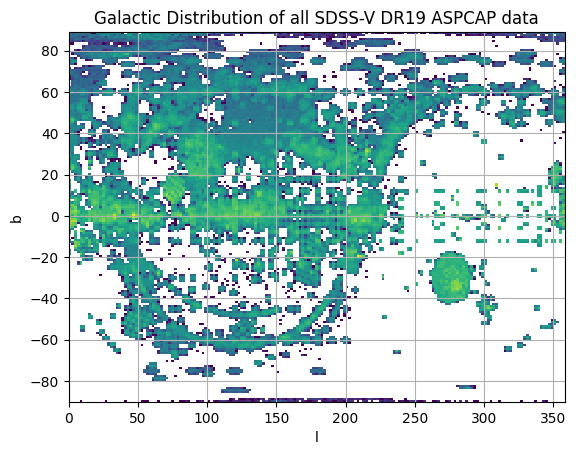

In [8]:
xcol, ycol = "l", "b"
xbins = np.arange(0, 360, 2)
ybins = np.arange(-90, 90, 1)
bins = [xbins, ybins]
iiplot = np.isfinite(t[xcol]) & np.isfinite(t[ycol])

plt.figure()
plt.hist2d(t[xcol][iiplot], t[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title('Galactic Distribution of all SDSS-V DR19 ASPCAP data')
#plt.title(f"{iiplot.sum()} stars")
plt.grid()#

You can see the impact of the selection function of different cartons in SDSS-V. One notable feature is the Magellanic Genesis carton at b\~-30 deg and l\~275 deg. When we instead look at the sky distribution of just Galactic Gensis data (below), we see this carton disappear.

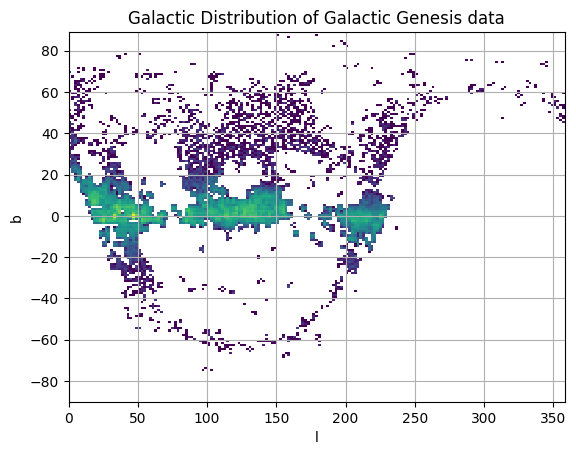

In [9]:
xcol, ycol = "l", "b"
xbins = np.arange(0, 360, 2)
ybins = np.arange(-90, 90, 1)
bins = [xbins, ybins]
iiplot = np.isfinite(gg_catalog[xcol]) & np.isfinite(gg_catalog[ycol])

plt.figure()
plt.hist2d(gg_catalog[xcol][iiplot], gg_catalog[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title('Galactic Distribution of Galactic Genesis data')
#plt.title(f"{iiplot.sum()} stars")
plt.grid()#

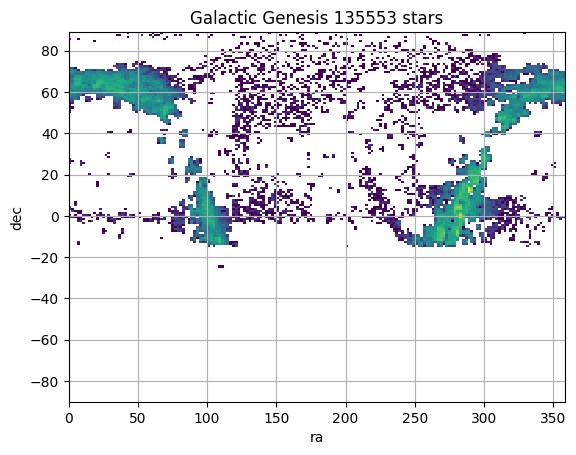

In [10]:
xcol, ycol = "ra", "dec"
xbins = np.arange(0, 360, 2)
ybins = np.arange(-90, 90, 1)
bins = [xbins, ybins]
iiplot = np.isfinite(gg_catalog[xcol]) & np.isfinite(gg_catalog[ycol])

plt.figure()
plt.hist2d(gg_catalog[xcol][iiplot], gg_catalog[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title(f"Galactic Genesis {iiplot.sum()} stars")
plt.grid()

Now we look at CMD. When we isolate to Galactic Genesis data we can see the photometric targeting selection, which aimed to select only giant stars.


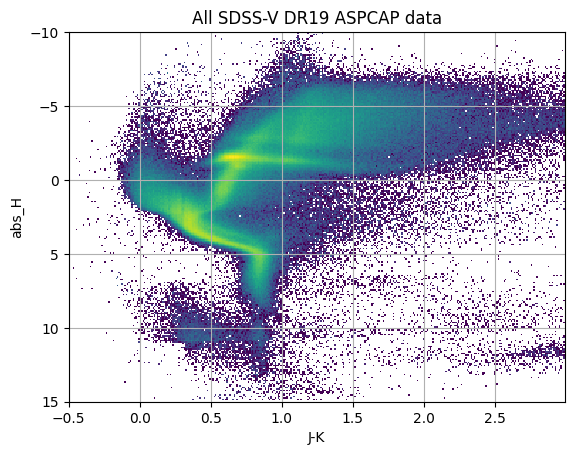

In [11]:


xcol, ycol = "J-K", "abs_H"
xbins = np.arange(-0.5, 3, 0.01)
ybins = np.arange(-10, 15, 0.1)
bins = [xbins, ybins]
iiplot = np.isfinite(t[xcol]) & np.isfinite(t[ycol])

plt.figure()
plt.hist2d(t[xcol][iiplot], t[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title("All SDSS-V DR19 ASPCAP data")
#plt.xlim(2,-1)
plt.ylim(15,-10)
plt.grid()

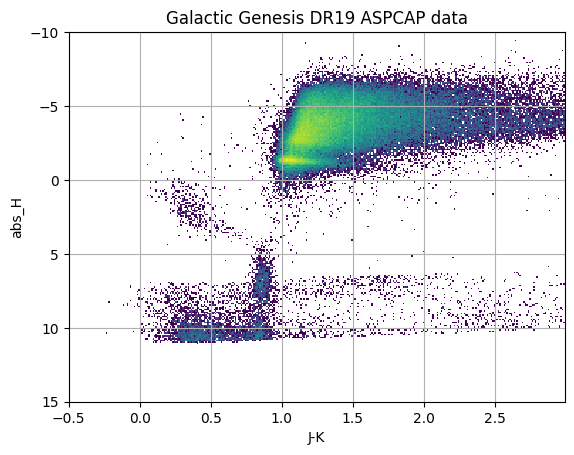

In [12]:
xcol, ycol = "J-K", "abs_H"
xbins = np.arange(-0.5, 3, 0.01)
ybins = np.arange(-10, 15, 0.1)
bins = [xbins, ybins]
iiplot = np.isfinite(gg_catalog[xcol]) & np.isfinite(gg_catalog[ycol])

plt.figure()
plt.hist2d(gg_catalog[xcol][iiplot], gg_catalog[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title("Galactic Genesis DR19 ASPCAP data")
#plt.xlim(2,-1)
plt.ylim(15,-10)
plt.grid()

The weird stuff at high abs_H is likely from bad distances

One thing to note: SDSS-IV spectra of stars also observed in SDSS-V are NOT coadded to SDSS-V spectra so they have seperate entries if observed in both


# Quality Flags

When working with SDSS-V data we recommened applying some quality flags. We have found this combination of flags to generally work well for selecting a trustworthy sample.


In [13]:
good_gg_inds = (gg_catalog["flag_bad"] == 0) & (gg_catalog["spectrum_flags"]==0) & (gg_catalog["snr"] > 40)

In [14]:
good_gg = gg_catalog[good_gg_inds]

print('Number of GG stars that pass quality cuts:'+str( len(good_gg)))
print('Total Number of GG stars:'+str( len(gg_catalog)))

Number of GG stars that pass quality cuts:72400
Total Number of GG stars:135553


# 3D Positions

Note that we are using Bailer-Jones photo-geometric distances.
These are not optimal at the distances that GG reaches, but good enough for this tutorial.
In DR19, there are provided distance catalogs from StarHorse and astroNN.

In [15]:
c = SkyCoord(t['ra']*u.deg,t['dec']*u.deg,distance=t['r_med_photogeo']*u.pc)

In [16]:
galcencoo = c.transform_to(acoo.Galactocentric)

In [17]:
## Add some geometric columns to the table
t["x"] = galcencoo.x.to("kpc").value
t["y"] = galcencoo.y.to("kpc").value
t["z"] = galcencoo.z.to("kpc").value
t["absz"] = np.abs(t["z"])
t["R"] = np.sqrt(t["x"]**2 + t["y"]**2)

In [18]:
good_gg = t[inds][good_gg_inds]

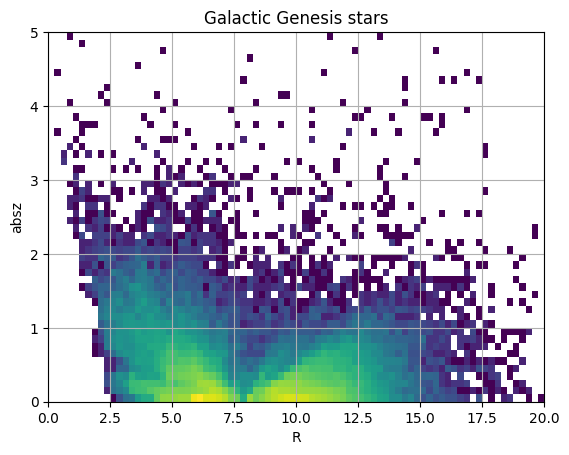

In [19]:
xcol, ycol = "R", "absz"
xbins = np.arange(0,20.1,.25)
ybins = np.arange(0,5.1,.1)
bins = [xbins, ybins]
iiplot = np.isfinite(good_gg[xcol]) & np.isfinite(good_gg[ycol])

plt.figure()
plt.hist2d(good_gg[xcol][iiplot], good_gg[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title("Galactic Genesis stars")
plt.grid()

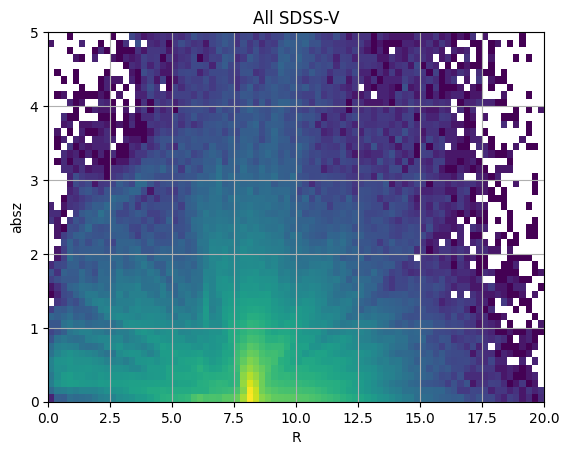

In [20]:
xcol, ycol = "R", "absz"
xbins = np.arange(0,20.1,.25)
ybins = np.arange(0,5.1,.1)
bins = [xbins, ybins]
iiplot = np.isfinite(t[xcol]) & np.isfinite(t[ycol])

plt.figure()
plt.hist2d(t[xcol][iiplot], t[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title("All SDSS-V")
plt.grid()

Showing everything in ASPCAP vs GG in ra, dec, and H to show selection function.
Observed to parent sample.

End point Plots: l vs b 2d histrogram
Kiel and/or CMD diagram
alpha vs fe
all as a function of quality and targeting flags


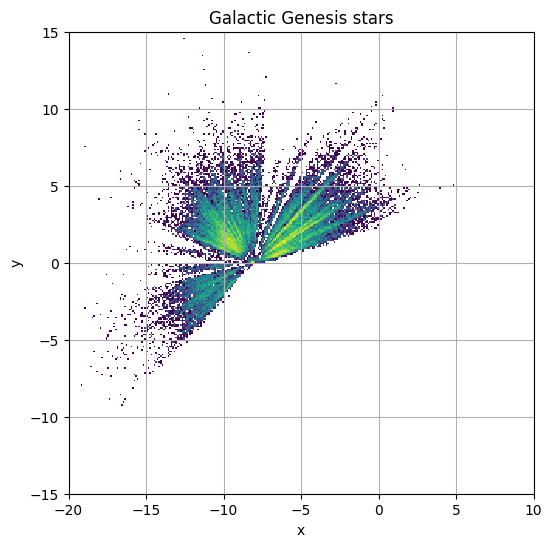

In [21]:
## Let's do the galaxy plane
xcol, ycol = "x", "y"
xbins = np.arange(-20,10.1,.1)
ybins = np.arange(-15,15.1,.1)
bins = [xbins, ybins]
iiplot = np.isfinite(good_gg[xcol]) & np.isfinite(good_gg[ycol]) & (good_gg["absz"] < 0.5)

plt.figure(figsize=(6,6))
plt.hist2d(good_gg[xcol][iiplot], good_gg[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title("Galactic Genesis stars")
plt.grid()

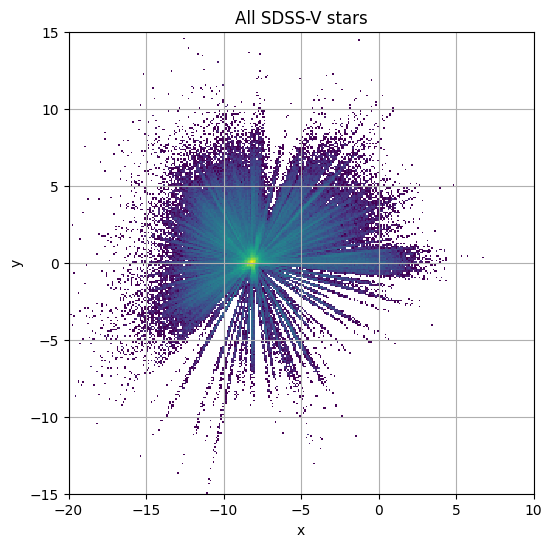

In [22]:
## Let's do the galaxy plane
xcol, ycol = "x", "y"
xbins = np.arange(-20,10.1,.1)
ybins = np.arange(-15,15.1,.1)
bins = [xbins, ybins]
iiplot = np.isfinite(t[xcol]) & np.isfinite(t[ycol]) & (t["absz"] < 0.5)

plt.figure(figsize=(6,6))
plt.hist2d(t[xcol][iiplot], t[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title("All SDSS-V stars")
plt.grid()

# ASPCAP results
We can seee that applying the quality flags removes many spurius stellar parameters that place stars in poorly modeled areas of the Kiel diagram.

(5.5, -1.0)

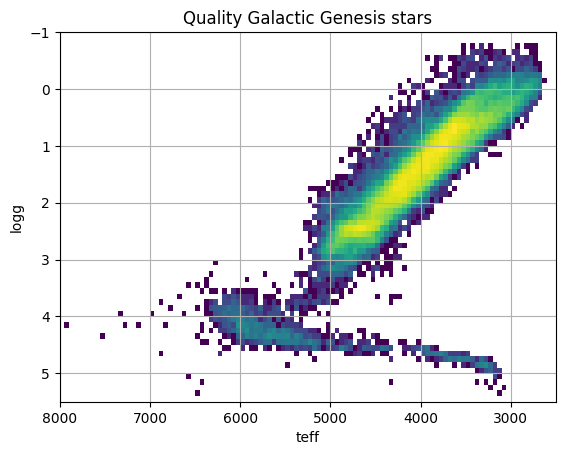

In [23]:
xcol, ycol = "teff", "logg"
xbins = np.arange(2000, 8000, 50)
ybins = np.arange(-1, 6, 0.1)
bins = [xbins, ybins]
iiplot = np.isfinite(good_gg[xcol]) & np.isfinite(good_gg[ycol])

plt.figure()
plt.hist2d(good_gg[xcol][iiplot], good_gg[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.grid()
plt.xlim(8000, 2500)
plt.title("Quality Galactic Genesis stars")
plt.ylim(5.5, -1)

(5.5, -1.0)

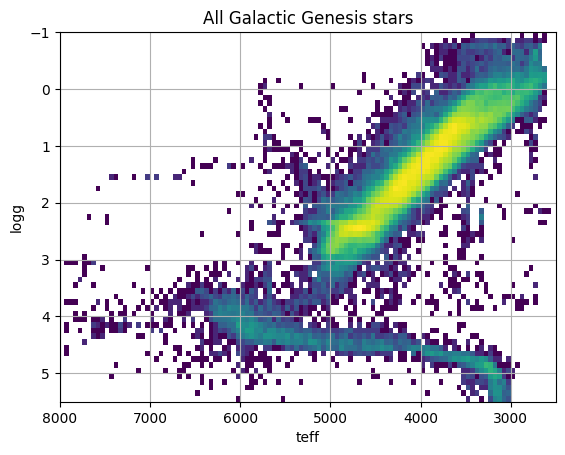

In [24]:
xcol, ycol = "teff", "logg"
xbins = np.arange(2000, 8000, 50)
ybins = np.arange(-1, 6, 0.1)
bins = [xbins, ybins]
iiplot = np.isfinite(gg_catalog[xcol]) & np.isfinite(gg_catalog[ycol])

plt.figure()
plt.hist2d(gg_catalog[xcol][iiplot], gg_catalog[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.grid()
plt.xlim(8000, 2500)
plt.title("All Galactic Genesis stars")
plt.ylim(5.5, -1)

(5.5, -1.0)

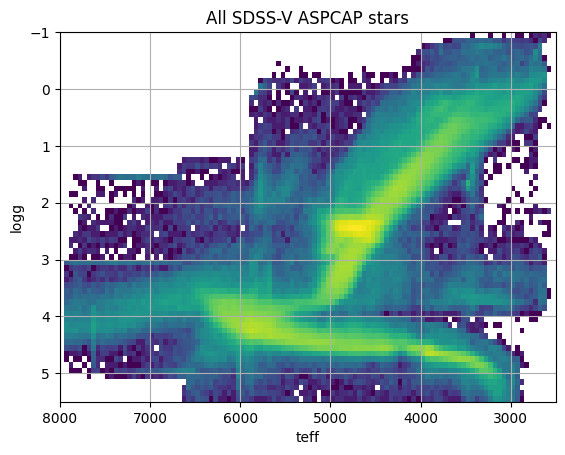

In [25]:
xcol, ycol = "teff", "logg"
xbins = np.arange(2000, 8000, 50)
ybins = np.arange(-1, 6, 0.1)
bins = [xbins, ybins]
iiplot = np.isfinite(t[xcol]) & np.isfinite(t[ycol])

plt.figure()
plt.hist2d(t[xcol][iiplot], t[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.grid()
plt.xlim(8000, 2500)
plt.title("All SDSS-V ASPCAP stars")
plt.ylim(5.5, -1)

# Elemental Abundances

Note that we include individual element flags here!! 

ASPCAP flags will catch grid edge issues in the analysis as shown in the below figures. It is important to apply flags to remove spurious abundance results


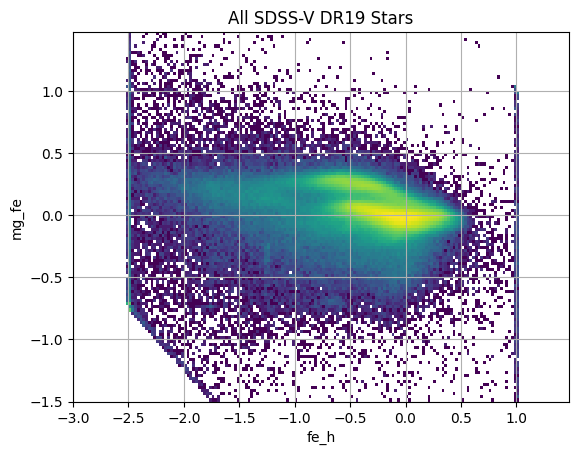

In [26]:
t['mg_fe'] = t['mg_h']-t['fe_h']
gg_catalog['mg_fe'] = gg_catalog['mg_h'] - gg_catalog['fe_h']
good_gg['mg_fe'] = good_gg['mg_h'] - good_gg['fe_h']

elem = "mg"
xcol, ycol = "fe_h", f"{elem}_fe"
xbins = np.arange(-3, 1.5, .025)
ybins = np.arange(-1.5, 1.5, 0.025)
bins = [xbins, ybins]
iiplot = np.isfinite(t[xcol]) & np.isfinite(t[ycol])

#no element flags in this plot
iiplot = iiplot

plt.figure()
plt.hist2d(t[xcol][iiplot], t[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title("All SDSS-V DR19 Stars")
plt.grid()

Weird Edge effects come from poor quality data/analysis


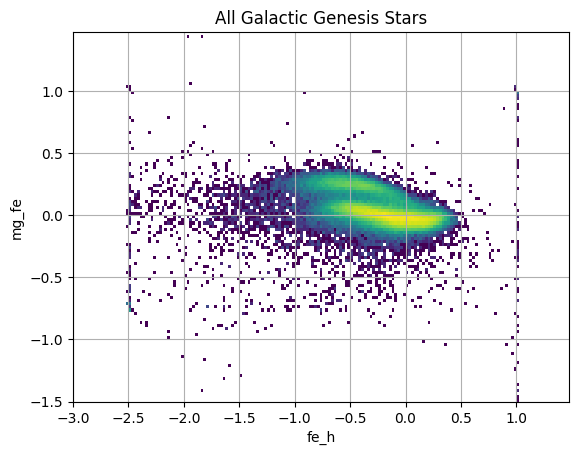

In [27]:

xcol, ycol = "fe_h", f"{elem}_fe"
xbins = np.arange(-3, 1.5, .025)
ybins = np.arange(-1.5, 1.5, 0.025)
bins = [xbins, ybins]
iiplot = np.isfinite(gg_catalog[xcol]) & np.isfinite(gg_catalog[ycol])

#no element flags in this plot
iiplot = iiplot

plt.figure()
plt.hist2d(gg_catalog[xcol][iiplot], gg_catalog[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title("All Galactic Genesis Stars")
plt.grid()

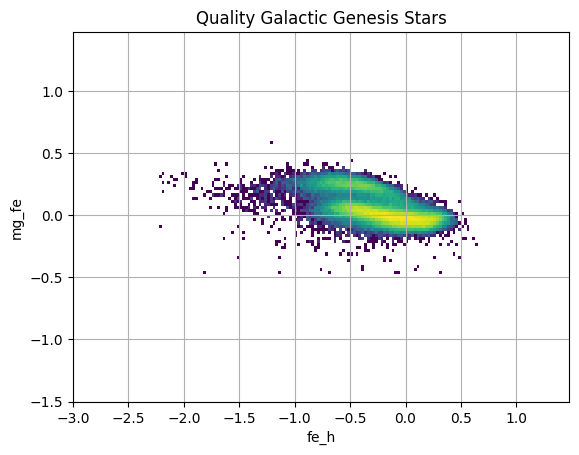

In [28]:

xcol, ycol = "fe_h", f"{elem}_fe"
xbins = np.arange(-3, 1.5, .025)
ybins = np.arange(-1.5, 1.5, 0.025)
bins = [xbins, ybins]
iiplot = np.isfinite(good_gg[xcol]) & np.isfinite(good_gg[ycol])

# Add element flags. Sometimes these abundances are OK, but we'll do a harsh cut for now.
iiplot = iiplot & (good_gg[f"{elem}_h_flags"] == 0) & (good_gg["fe_h_flags"] == 0)

plt.figure()
plt.hist2d(good_gg[xcol][iiplot], good_gg[ycol][iiplot],
           bins=bins,
           norm=LogNorm(), cmap="viridis")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title("Quality Galactic Genesis Stars")
plt.grid()

### About this notebook
This notebook was created to demonstrate usage of the astarAllStarASPCAP file, explore the Galactic Genesis cartoon and proivde recommened quality flags.

__Authors__: Madeline Lucey, Alex Ji, Jon Bird, James Johnson, Sarah Loebman, Melissa Ness, with thanks to Ilija Medan and John Donor

__Last Update__: 2026 Mar 05

If you use `astropy` for published research, please cite the authors. Follow this link for more information about citing astropy:

- [Citing `astropy`
](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/)SDSS when you use our data.